In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import nlp_processor

In [ ]:
def tag_telkomsel_reviews():
    input_csv = "dataset_telkomsel/telkomsel_reguler_reviews_raw.csv"
    output_csv = "dataset_telkomsel/tsel_reguler_reviews_tagged.csv"
    
    # Memanggil fungsi pipeline dari nlp_processor.py
    nlp_processor.process_nlp_pipeline(input_csv, output_csv)

# Eksekusi Tagging
tag_telkomsel_reviews()

[*] Memuat data mentah dari: dataset_telkomsel/telkomsel_reguler_reviews_raw.csv
[*] Mengeksekusi sanitasi teks dan klasifikasi...
[SUCCESS] Pemrosesan NLP selesai. Data diekspor ke: dataset_telkomsel/tsel_reguler_reviews_tagged.csv

=== Distribusi Kategori Keluhan ===
complaint_category
General/Other                               9057
Pricing/Billing                             3539
Network/QoS                                 3480
Pricing/Billing, Network/QoS                3261
Pricing/Billing, Network/QoS, App/System    1849


[*] Memulai komputasi analitik Telkomsel (Termasuk Tren Sentimen Harga)...
[SUCCESS] Dashboard diperbarui dengan metrik Harga! Artefak: dashboard_output/telkomsel_portfolio_dashboard_final.png


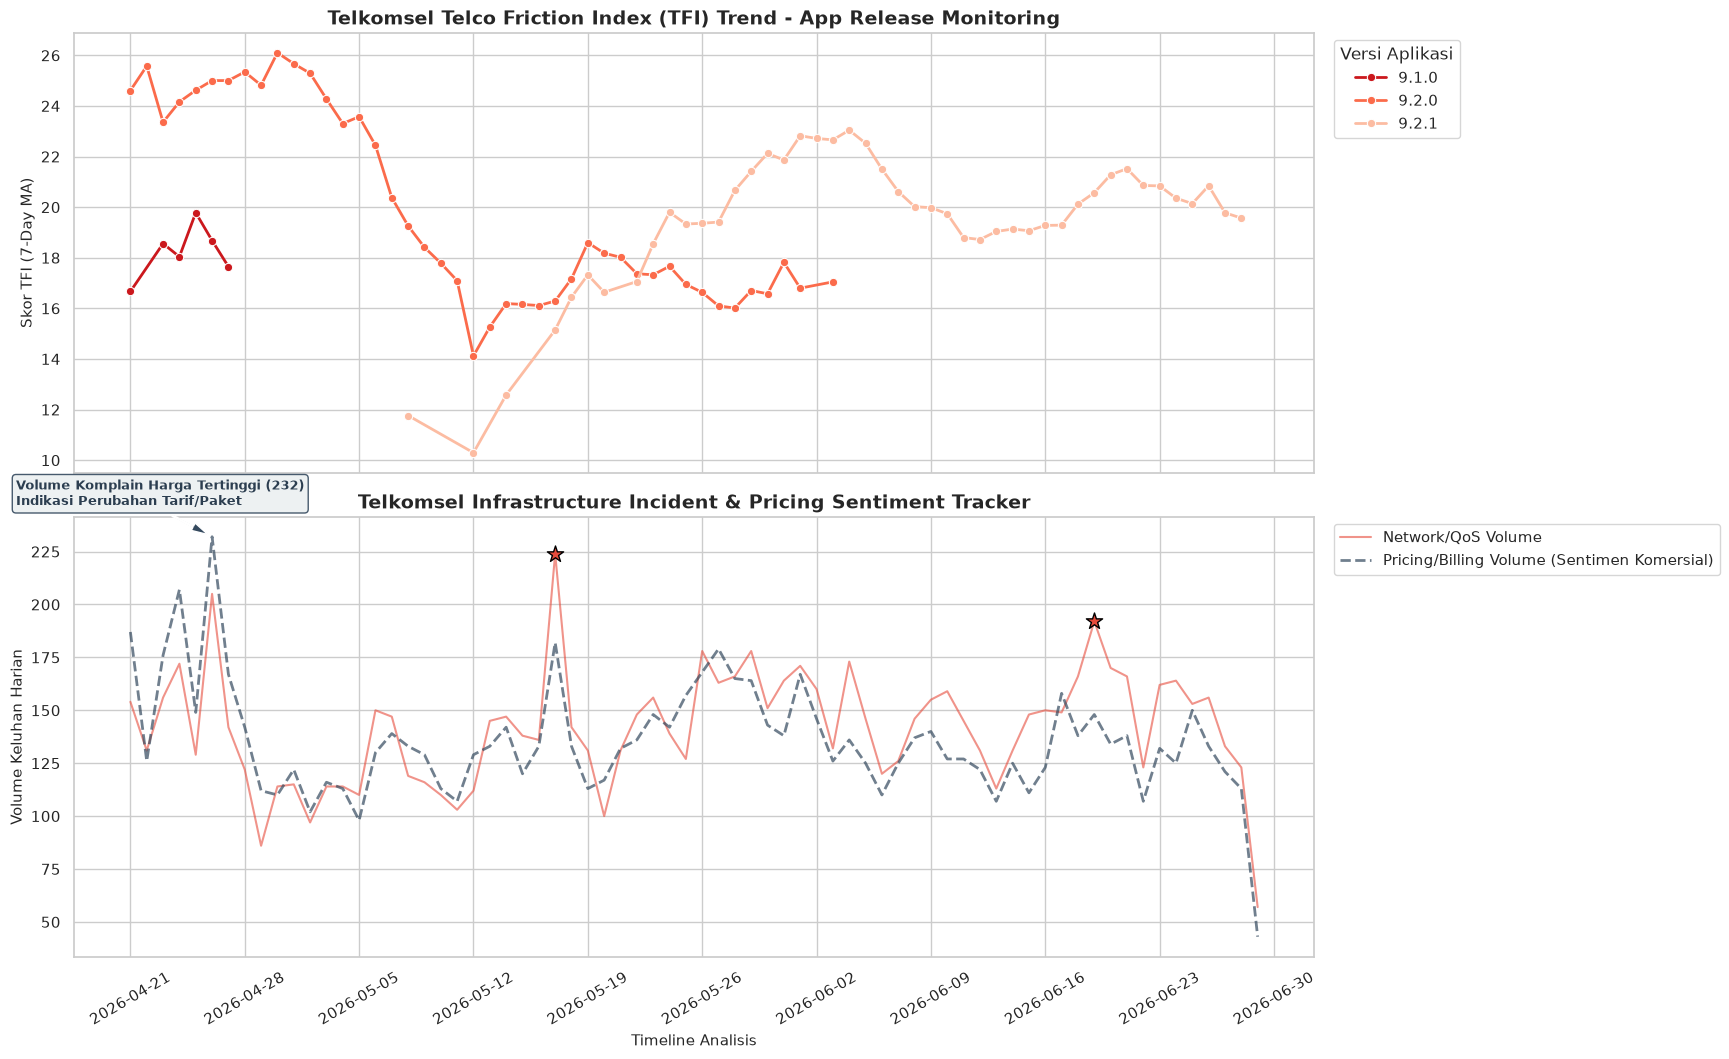

In [4]:
def generate_telkomsel_dashboard():
    print("[*] Memulai komputasi analitik Telkomsel (Termasuk Tren Sentimen Harga)...")
    
    # 1. Memuat Dataset
    df = pd.read_csv('dataset_telkomsel/tsel_reguler_reviews_tagged.csv', parse_dates=['at'])
    df['date'] = df['at'].dt.date
    
    # =======================================================
    # FASE A: KALKULASI TFI (Tetap dipertahankan)
    # =======================================================
    df_app = df[df['complaint_category'].str.contains('App/System', na=False)]
    app_daily = df_app.groupby(['date', 'reviewCreatedVersion']).size().reset_index(name='app_complaints')
    total_daily = df.groupby(['date', 'reviewCreatedVersion']).size().reset_index(name='total_complaints')
    
    tfi_df = pd.merge(total_daily, app_daily, on=['date', 'reviewCreatedVersion'], how='left').fillna(0)
    tfi_df['TFI'] = (tfi_df['app_complaints'] / tfi_df['total_complaints']) * 100
    
    threshold = tfi_df['total_complaints'].quantile(0.90)
    tfi_df_filtered = tfi_df[tfi_df['total_complaints'] >= threshold].copy()
    tfi_df_filtered.sort_values(by=['reviewCreatedVersion', 'date'], inplace=True)
    tfi_df_filtered['TFI_MA_7D'] = tfi_df_filtered.groupby('reviewCreatedVersion')['TFI'].transform(lambda x: x.rolling(7, min_periods=1).mean())
    
    # =======================================================
    # FASE B: EKSTRAKSI TREN HARGA & JARINGAN
    # =======================================================
    df_exploded = df.assign(complaint_category=df['complaint_category'].str.split(', ')).explode('complaint_category')
    daily_vol = df_exploded.groupby(['date', 'complaint_category']).size().reset_index(name='volume')
    pivot_vol = daily_vol.pivot(index='date', columns='complaint_category', values='volume').fillna(0)
    pivot_vol.index = pd.to_datetime(pivot_vol.index)
    
    # =======================================================
    # FASE C: RENDER CANVAS
    # =======================================================
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    
    # --- PANEL 1: TFI ---
    tfi_plot = tfi_df_filtered[tfi_df_filtered['date'] != tfi_df_filtered['date'].max()].copy()
    real_versions = tfi_plot[tfi_plot['reviewCreatedVersion'] != 'Unknown_Version']
    top_versions = real_versions.groupby('reviewCreatedVersion')['total_complaints'].sum().nlargest(4).index
    df_plot_tfi = tfi_plot[tfi_plot['reviewCreatedVersion'].isin(top_versions)]
    
    sns.lineplot(
        data=df_plot_tfi, x='date', y='TFI_MA_7D', hue='reviewCreatedVersion', 
        marker='o', linewidth=2, ax=axes[0], palette="Reds_r"
    )
    axes[0].set_title('Telkomsel Telco Friction Index (TFI) Trend - App Release Monitoring', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Skor TFI (7-Day MA)', fontsize=11)
    axes[0].legend(title='Versi Aplikasi', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    # --- PANEL 2: INFRASTRUCTURE & PRICING TRACKER ---
    # 1. Plot Jaringan (Baseline & Z-Score)
    if 'Network/QoS' in pivot_vol.columns:
        axes[1].plot(pivot_vol.index, pivot_vol['Network/QoS'], label='Network/QoS Volume', color='#e74c3c', alpha=0.6, linewidth=1.5)
        
        mean = pivot_vol['Network/QoS'].rolling(window=14, min_periods=1).mean()
        std = pivot_vol['Network/QoS'].rolling(window=14, min_periods=1).std().replace(0, np.nan)
        z_score = ((pivot_vol['Network/QoS'] - mean) / std).fillna(0)
        
        anomalies = pivot_vol[z_score > 2.0]
        if not anomalies.empty:
            axes[1].scatter(anomalies.index, anomalies['Network/QoS'], color='#e74c3c', edgecolor='black', s=150, zorder=5, marker='*')

    # 2. Plot Pricing/Billing (Injeksi Metrik Sekunder)
    if 'Pricing/Billing' in pivot_vol.columns:
        # Menggunakan garis putus-putus abu-abu gelap agar tidak mengganggu fokus radar utama Jaringan
        axes[1].plot(
            pivot_vol.index, pivot_vol['Pricing/Billing'], 
            label='Pricing/Billing Volume (Sentimen Komersial)', 
            color='#34495e', linestyle='--', alpha=0.7, linewidth=2
        )
        
        # Temukan titik puncak keluhan harga untuk anotasi catatan kaki visual
        peak_pricing_date = pivot_vol['Pricing/Billing'].idxmax()
        peak_pricing_val = pivot_vol['Pricing/Billing'].max()
        
        axes[1].annotate(
            f'Volume Komplain Harga Tertinggi ({int(peak_pricing_val)})\nIndikasi Perubahan Tarif/Paket', 
            xy=(peak_pricing_date, peak_pricing_val), 
            xytext=(peak_pricing_date - pd.Timedelta(days=12), peak_pricing_val + 15),
            arrowprops=dict(facecolor='#34495e', shrink=0.08, width=1, headwidth=6),
            fontsize=9, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle="round,pad=0.3", fc="#ecf0f1", ec="#34495e", alpha=0.9)
        )

    axes[1].set_title('Telkomsel Infrastructure Incident & Pricing Sentiment Tracker', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Volume Keluhan Harian', fontsize=11)
    axes[1].set_xlabel('Timeline Analisis', fontsize=11)
    axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    
    # Formatting sumbu X
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.tick_params(axis='x', rotation=30)
        
    plt.subplots_adjust(hspace=0.1)
    output_path = 'dashboard_output/telkomsel_portfolio_dashboard_final.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[SUCCESS] Dashboard diperbarui dengan metrik Harga! Artefak: {output_path}")

# Jalankan fungsi
generate_telkomsel_dashboard()